# Tutorial 10 - New environments

Let's learn how to use PPO with a few different kinds of environments:
- continuous actions (we saw last time)
- discreate actions (let's see how to setup PPO)
- Visual inputs (arcade action)
- time series data (stocks RNNs)
- Run many environments in parallel
- Stationary vs non-stationary & fully observable vs partially observable

From this point onwards students can do their projects! 

In [1]:
import torchvision 

from tensordict.nn import TensorDictSequential

import torch
from tensordict.nn import TensorDictModule
from tensordict import TensorDict
from torchrl.envs import GymEnv, check_env_specs
from torch import nn

from torchrl.modules import QValueActor
from torch.optim import Adam, RMSprop
from torchrl.modules import QValueActor

In [3]:
#!pip install swig
#!pip install "gymnasium[box2d]"`

### Continuous actions

Let's try out our PPO code on a continuous action space: racing car!

In [4]:
from torchrl.envs import TransformedEnv, Compose, ObservationNorm, DoubleToFloat, StepCounter, RewardScaling
from torchrl.objectives import A2CLoss
from torchrl.objectives.value import TD0Estimator

# check out the env here: https://gymnasium.farama.org/environments/box2d/car_racing/
base_env = GymEnv("CarRacing-v3")

#build the environment with some transforms
env = TransformedEnv(
    base_env,
    Compose(
        # normalize observations
        #ObservationNorm(in_keys=["observation"]),
        DoubleToFloat(),
        StepCounter(),
        #RewardScaling(loc=0, scale=0.01),
    ),
)
#env.transform[0].init_stats(num_iter=1000, reduce_dim=0, cat_dim=0)

rollout_data = env.rollout(50)
rollout_data

TensorDict(
    fields={
        action: Tensor(shape=torch.Size([50, 3]), device=cpu, dtype=torch.float32, is_shared=False),
        done: Tensor(shape=torch.Size([50, 1]), device=cpu, dtype=torch.bool, is_shared=False),
        next: TensorDict(
            fields={
                done: Tensor(shape=torch.Size([50, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                pixels: Tensor(shape=torch.Size([50, 96, 96, 3]), device=cpu, dtype=torch.uint8, is_shared=False),
                reward: Tensor(shape=torch.Size([50, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                step_count: Tensor(shape=torch.Size([50, 1]), device=cpu, dtype=torch.int64, is_shared=False),
                terminated: Tensor(shape=torch.Size([50, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                truncated: Tensor(shape=torch.Size([50, 1]), device=cpu, dtype=torch.bool, is_shared=False)},
            batch_size=torch.Size([50]),
            device=None,
      

In [5]:
import matplotlib.pyplot as plt
frame = rollout_data["pixels"][49,:,:,:]
frame

tensor([[[100, 202, 100],
         [100, 202, 100],
         [100, 202, 100],
         ...,
         [100, 202, 100],
         [100, 202, 100],
         [100, 202, 100]],

        [[100, 202, 100],
         [100, 202, 100],
         [100, 202, 100],
         ...,
         [100, 202, 100],
         [100, 202, 100],
         [100, 202, 100]],

        [[100, 202, 100],
         [100, 202, 100],
         [100, 202, 100],
         ...,
         [100, 202, 100],
         [100, 202, 100],
         [100, 202, 100]],

        ...,

        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0]],

        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0]],

        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [  0,   0,   0],
        

Notice there is no observations, but there are pixels!

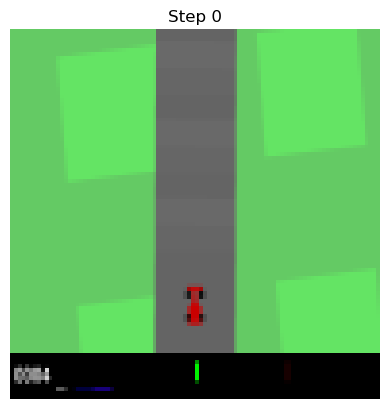

In [6]:
plt.imshow(frame)
plt.title("Step 0")
plt.axis("off")
plt.show()

You should be able to see the image that our agent will use to learn how to drive! A 96x96 RGB image of the car and race track.

Unfortunately there is a little inconsistency between how gymnasium sets up their image data and how torch wants it, so we'll have to do some preprocessing just to get the right order.

Gymnasium outputs (batch, image height, image width, channel/color)
Torch expects (batch, channel/color, image height, image width)



In [7]:

# mismatch between gym and torch: let's convert the image data: (B,H,W,C) --> (B,C,H,W)
class Preprocess(nn.Module):
    def forward(self, x):
        x = x.float() / 255.0
        if x.ndim == 3:  # (H, W, C) -> add batch dim
            x = x.unsqueeze(0).permute(0, 3, 1, 2)  # (1, C, H, W)
        else:            # (B, H, W, C) -> already batched
            x = x.permute(0, 3, 1, 2)               # (B, C, H, W)
        return x
    
preprocess = Preprocess()      
test_shape = preprocess(frame)  
print(test_shape.shape)         # Should now show the correct B,C,H,W

torch.Size([1, 3, 96, 96])


Next, let's setup how it will control actions!

#### Actor

The agent will have to control the car using:

* 0: steering, -1 is full left, +1 is full right

* 1: gas

* 2: braking

We can see the range of values we can use for these actions

In [8]:
print(f'Min actions: {env.action_spec_unbatched.space.low}')
print(f'Max action: {env.action_spec_unbatched.space.high}')

Min actions: tensor([-1.,  0.,  0.])
Max action: tensor([1., 1., 1.])


In [9]:

from torchrl.modules import ProbabilisticActor, TanhNormal
from torchrl.modules import NormalParamExtractor

num_cells = 256
device = "cpu"


# we should know the dimensions after the convolution
cnn_feature_dim = 64 * 8 * 8  # = 4096

#fix actions to be (3,) not (1,3)
class SqueezeIfUnbatched(nn.Module):
    def forward(self, x):
        if x.shape[0] == 1:
            return x.squeeze(0)
        return x

# actor
actor_net = nn.Sequential(
    Preprocess(),
    nn.Conv2d(3, 32, kernel_size=8, stride=4),
    nn.ReLU(),
    nn.Conv2d(32, 64, kernel_size=4, stride=2),
    nn.ReLU(),
    nn.Conv2d(64, 64, kernel_size=3, stride=1),
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear(cnn_feature_dim, num_cells),
    nn.Tanh(),
    nn.Linear(num_cells, num_cells),
    nn.Tanh(),
    nn.Linear(num_cells, 2 * env.action_spec.shape[-1]),
    SqueezeIfUnbatched(),
    NormalParamExtractor(),
)

policy_module = TensorDictModule(
    actor_net, in_keys=["pixels"], out_keys=["loc", "scale"] #need to change what goes in here to pixels!
)

policy_module = ProbabilisticActor(
    module=policy_module,
    spec=env.action_spec,
    in_keys=["loc", "scale"],
    distribution_class=TanhNormal,
    distribution_kwargs={
        "low": env.action_spec_unbatched.space.low,
        "high": env.action_spec_unbatched.space.high,
    },
    return_log_prob=True,
    safe=True,
)


Note: here the TanhNormal distribution is very useful for bounding the action space of our agent to [[-1,1], [0,1], [0,1]]

Let's test the policy by giving it outputs from the environment and checking that it can choose some actions

In [10]:
test = env.rollout(10)
outpts = policy_module(test)
outpts["action"]

tensor([[0.0306, 0.4996, 0.5079],
        [0.0299, 0.4997, 0.5076],
        [0.0285, 0.5000, 0.5088],
        [0.0288, 0.4991, 0.5092],
        [0.0297, 0.4995, 0.5094],
        [0.0296, 0.4991, 0.5101],
        [0.0294, 0.4995, 0.5111],
        [0.0293, 0.4999, 0.5108],
        [0.0277, 0.4996, 0.5103],
        [0.0283, 0.4996, 0.5102]], grad_fn=<AddBackward0>)

You should see some reasobable actions here, at least within resonable ranges!

In [11]:
single_frame = env.reset()
print("reset pixels shape:", single_frame["pixels"].shape)
out = policy_module(single_frame)
print("action shape:", out["action"].shape)
print("action:", out["action"])

reset pixels shape: torch.Size([96, 96, 3])
action shape: torch.Size([3])
action: tensor([0.0307, 0.5000, 0.5079], grad_fn=<AddBackward0>)


You should also see that it generated some action_log_prob values! Will be very useful!

Next let's setup the critic just like we did before, just with pixels

#### Critic

In [12]:

#create a model: takes observations as inputs, and outputs categorical actions
model = nn.Sequential(
    Preprocess(),
    nn.Conv2d(3, 32, kernel_size=8, stride=4),
    nn.ReLU(),
    nn.Conv2d(32, 64, kernel_size=4, stride=2),
    nn.ReLU(),
    nn.Conv2d(64, 64, kernel_size=3, stride=1),
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear(cnn_feature_dim, num_cells),
    nn.Tanh(),
    nn.Linear(num_cells, num_cells),
    nn.Tanh(),
    nn.Linear(num_cells, 1),
)

#go from observations to logits using the model
value_net = TensorDictModule(
    model,
    in_keys=["pixels"], #we need to change this to pixels here too!
    out_keys=["state_value"],          
)




Let's test the critic

In [13]:
# Initialize lazy layers with a dummy forward pass
dummy_td = env.reset()
estimated_value = value_net(dummy_td)       # initializes critic lazy layers
estimated_value

TensorDict(
    fields={
        done: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False),
        pixels: Tensor(shape=torch.Size([96, 96, 3]), device=cpu, dtype=torch.uint8, is_shared=False),
        state_value: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.float32, is_shared=False),
        step_count: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.int64, is_shared=False),
        terminated: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False),
        truncated: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False)},
    batch_size=torch.Size([]),
    device=None,
    is_shared=False)

We should see some estimated state values!

In [14]:
estimated_value["state_value"]


tensor([[0.0228]], grad_fn=<AddmmBackward0>)

Now that our agent can estimate state values from observations, and it can choose actions from observations, let's train it so that it can learn to drive better.

#### Training loop

Let's train!

**Rewards**
The reward is -0.1 every frame and +1000/N for every track tile visited, where N is the total number of tiles visited in the track. For example, if you have finished in 732 frames, your reward is 1000 - 0.1*732 = 926.8 points.

In [15]:
from pathlib import Path

# ── Checkpointing setup ────────────────────────────────────────────────────────
checkpoint_dir = Path("checkpoints")
checkpoint_dir.mkdir(exist_ok=True)
save_every = 10        # save every N batches
best_reward = -float("inf")

def save_checkpoint(batch_idx, reward, tag="latest"):
    torch.save({
        "batch_idx": batch_idx,
        "reward": reward,
        "policy": policy_module.state_dict(),
        "critic": value_net.state_dict(),
        "optimizer": optim.state_dict(),
    }, checkpoint_dir / f"checkpoint_{tag}.pt")


In [ ]:


from torchrl.collectors import SyncDataCollector
from torchrl.data import LazyTensorStorage, ReplayBuffer, SamplerWithoutReplacement
from torchrl.record import CSVLogger
import torch.nn.functional as F

logger = CSVLogger(exp_name="my_exp")

frames_per_batch = 1000
total_frames = 1_000_000
gamma = 0.99



from torchrl.objectives import ClipPPOLoss
from torchrl.objectives.value import GAE

loss_fn = ClipPPOLoss(
    actor_network=policy_module,
    critic_network=value_net,
    clip_epsilon=0.2,        # the ε — constrains how much policy can change
    entropy_bonus=True,
    entropy_coeff=0.5,
    critic_coeff=0.5,
    loss_critic_type="l2",
)

adv_module = GAE(
    gamma=0.99,
    lmbda=0.95,
    value_network=value_net,
    average_gae=True,
)

# PPO uses a replay buffer to do multiple epochs over the same batch, though no data is kept between batches
from torchrl.data import LazyTensorStorage, ReplayBuffer, SamplerWithoutReplacement

frames_per_batch = 1000   
num_epochs = 10          # learn from each batch 10 times
minibatch_size = 50      # update on 50-frame minibatches within each epoch

replay_buffer = ReplayBuffer(
    storage=LazyTensorStorage(frames_per_batch),
    sampler=SamplerWithoutReplacement(),  # ensures each sample used once per epoch
    batch_size=20
)

collector = SyncDataCollector(
    env,
    policy_module,
    frames_per_batch=frames_per_batch,
    total_frames=total_frames,
    split_trajs=False,
    device=device,
)

optim = Adam(loss_fn.parameters(), lr=0.00004)  

for i, data in enumerate(collector):
    reward = data["next", "reward"].squeeze(-1)

    # Compute GAE advantages once for the whole batch
    with torch.no_grad():
        adv_module(data)

    # Store the batch in the replay buffer
    replay_buffer.extend(data)

    # Now do K epochs of minibatch updates
    for epoch in range(num_epochs):
        for minibatch in replay_buffer:  # SamplerWithoutReplacement covers full batch once
            loss_td = loss_fn(minibatch)
            loss = loss_td["loss_objective"] + loss_td["loss_critic"] + loss_td["loss_entropy"]

            optim.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(loss_fn.parameters(), max_norm=0.5)
            optim.step()

    mean_reward = reward.mean().item()
    # save latest checkpoint every N batches
    if i % save_every == 0:
        save_checkpoint(i, mean_reward, tag="latest")

    # save best checkpoint whenever reward improves
    if mean_reward > best_reward:
        best_reward = mean_reward
        save_checkpoint(i, mean_reward, tag="best")
    
    print(
        f"Reward: {reward.mean():+7.3f} | "
        f"Actor Loss: {loss_td['loss_objective'].item():+7.3f} | "
        f"Critic Loss: {loss_td['loss_critic'].item():7.3f} | "
        f"Entropy: {loss_td['loss_entropy'].item():+7.4f} | "
        f"Clip frac: {loss_td['clip_fraction'].item():.3f}"
    )


/home/titan2/data/conda-envs/torchrl_latest/lib/python3.12/site-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(


2026-03-16 09:11:04,202 [torchrl][INFO]    Initialized LazyTensorStorage with torch.Size([1000]) shape [END]
Reward:  -0.039 | Actor Loss:  +0.188 | Critic Loss:   0.291 | Entropy: -0.3574 | Clip frac: 0.150
Reward:  -0.038 | Actor Loss:  +0.009 | Critic Loss:   0.343 | Entropy: -0.3164 | Clip frac: 0.100
Reward:  -0.031 | Actor Loss:  -0.129 | Critic Loss:   0.567 | Entropy: -0.3908 | Clip frac: 0.050
Reward:  -0.027 | Actor Loss:  -0.090 | Critic Loss:   0.448 | Entropy: -0.3584 | Clip frac: 0.000
Reward:  -0.026 | Actor Loss:  -0.340 | Critic Loss:   0.498 | Entropy: -0.3399 | Clip frac: 0.100
Reward:  -0.030 | Actor Loss:  +0.040 | Critic Loss:   0.319 | Entropy: -0.2791 | Clip frac: 0.050
Reward:  -0.034 | Actor Loss:  -0.199 | Critic Loss:   0.376 | Entropy: -0.3821 | Clip frac: 0.000
Reward:  -0.028 | Actor Loss:  +0.114 | Critic Loss:   0.137 | Entropy: -0.3686 | Clip frac: 0.100
Reward:  -0.030 | Actor Loss:  -0.155 | Critic Loss:   0.086 | Entropy: -0.3563 | Clip frac: 0.000


Let's see how good the trained model is! 

Let's load in the best model, and try it out in the environment.